# DS 542 Fall 2025 Project 2

Your task for this project to design and train a convolutional neural network classifying pictures of butterflies from [iNaturalist](https://www.inaturalist.org) by species.


## Background

The iNaturalist project crowdsources observations of wildlife including images, location, timestamp, and species identification.

Here is an example image from [an observation of a Monarch butterfly](https://www.inaturalist.org/observations/231456432).

![Danaus plexippus plexippus](https://inaturalist-open-data.s3.amazonaws.com/photos/411089128/medium.jpeg)


## Data

For this project, observations and images for many butterfly species were collected in a GitHub repository.

  https://github.com/DL4DS/butterflies

**Checking out this repository requires about 21GB of disk space.**
This repository is checked out on the Shared Compute Cluster (SCC) at `/projectnb/dl4ds/materials/datasets/butterflies`.

## Outline

1. Visualize species distribution and prepare to classify top 9 species.
2. Implement Torch DataSet and DataLoader objects to simplify data access.
3. Define model structure and select an appropriate loss function.
4. Implement a training loop and explain your choices.
5. Predict species for the test set.

## Modules

In [1]:
import pandas as pd
import torch
import numpy as np
import os 

import matplotlib.pyplot as plt
# Add any other imports you need

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Part 1: Visualize species distribution and prepare to classify top 9 species.

### Plot a histogram of species in the training data set.

Don't worry about cleaning up possible duplicates.
Just use the species names as is.

In [3]:
data_dir = "/projectnb/dl4ds/materials/datasets/butterflies"

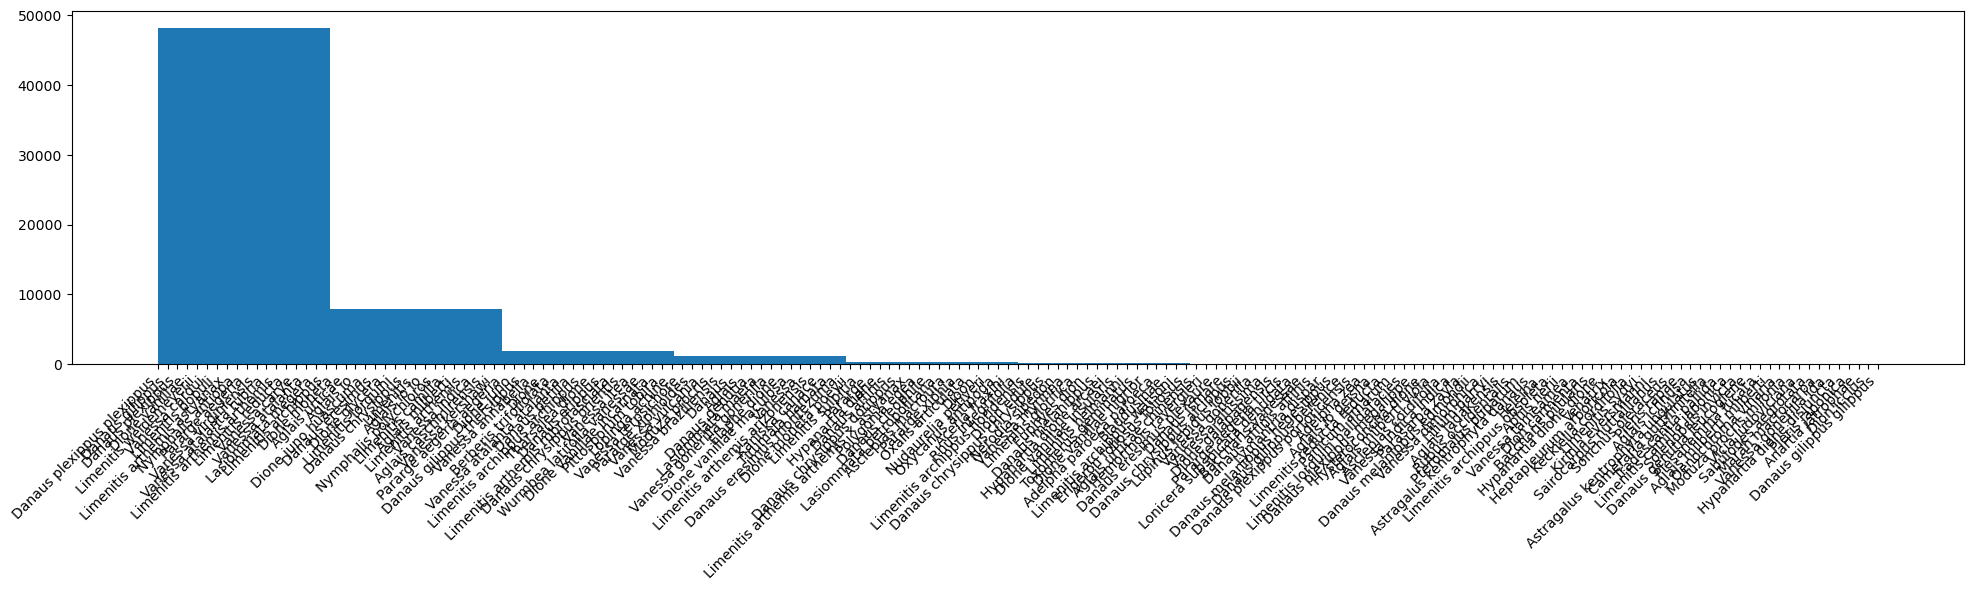

In [4]:
# YOUR CHANGES HERE

def import_data(t): 
    images = pd.read_csv(f"{data_dir}/{t}.csv")
    return images

df = import_data("train")
# counts = df['scientific_name'].value_counts()
# species_name = list(counts.index)
# species_value = list(counts)
plt.figure(figsize=(20, 6))
plt.hist(df['scientific_name'])
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

### Plot a histogram of the top 9 species plus an "Other" category for the other species.

Use the training data set again.

{'Danaus plexippus': 0, 'Vanessa atalanta': 1, 'Dione vanillae': 2, 'Aglais io': 3, 'Pararge aegeria': 4, 'Vanessa virginiensis': 5, 'Vanessa cardui': 6, 'Nymphalis antiopa': 7, 'Danaus gilippus': 8, 'other': 9}
{0: 'Danaus plexippus', 1: 'Vanessa atalanta', 2: 'Dione vanillae', 3: 'Aglais io', 4: 'Pararge aegeria', 5: 'Vanessa virginiensis', 6: 'Vanessa cardui', 7: 'Nymphalis antiopa', 8: 'Danaus gilippus', 9: 'other'}


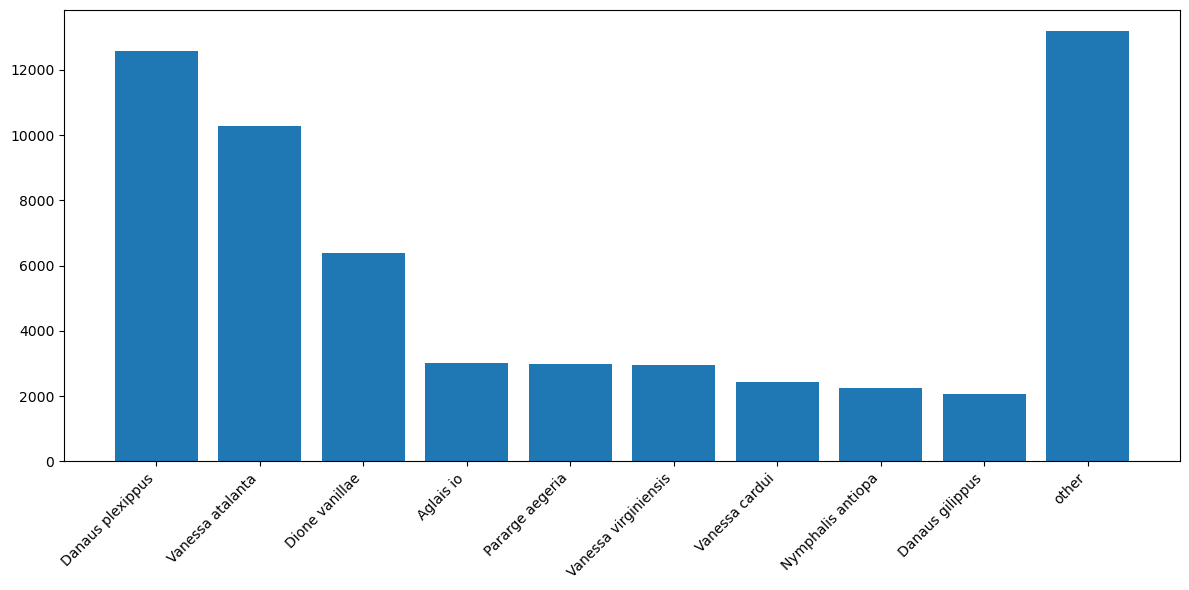

In [5]:
# YOUR CHANGES HERE

def find_top_10_species(df, name): 
    groups = df[name].value_counts()
    
    others_val = sum(list(groups)[10:]) 
    
    counts = list(groups)[0:10]
    counts[-1] = others_val

    species_name = list(groups.index)[0:10]
    species_name[-1] = "other" 

    return species_name, counts 


train_species, counts = find_top_10_species(df=df, name="scientific_name")


name_to_id = {v: k for k, v in enumerate(train_species)}
print(name_to_id)
id_to_name = {v: k for k,v in name_to_id.items()}
print(id_to_name)

plt.figure(figsize=(12, 6))
plt.bar(train_species, counts)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Write files "train-onehot.csv" and "validation-onehot.csv".

These will facilitate your data management later.
The columns for both files should be `uuid` and `image_path` from either "train.csv" or "validation.csv", followed by the top 9 species in the training data set in order, followed by `other`.
The values for the species and `other` columns should all be zero or one.

In [6]:
import torch.nn.functional as F

SPECIES = list(train_species)
def convert_series_to_one_hot(df, name): 
    df = df.copy()
    df[name] = df[name].map(lambda x: "other" if x not in SPECIES else x) 
    df["value"] = df[name].map(name_to_id) 
    print(df['value'])
    vector_tensor = torch.Tensor(df['value']).long()
    one_hot_df = pd.DataFrame(F.one_hot(vector_tensor).detach().numpy()) 
    one_hot_df.columns = one_hot_df.columns.map(id_to_name)

    return df[['uuid', 'image_path']].merge(one_hot_df, on=df.index).drop('key_0', axis=1)


new_df = convert_series_to_one_hot(df, "scientific_name")
print(new_df)
new_df.to_csv("train-onehot.csv", index=False)

0        9
1        8
2        0
3        2
4        9
        ..
59746    0
59747    0
59748    0
59749    1
59750    9
Name: value, Length: 59751, dtype: int64
                                       uuid  \
0      5994c404-c52b-4833-ace9-eecdd76cf149   
1      6cb21298-a76e-4693-abc5-c5ddea93ffbe   
2      6f34b554-3cc9-4175-a9ec-13572e096e5c   
3      59aff41d-9a5f-40ec-84a5-bc422b4c8939   
4      9258b964-304e-4030-9c10-2477a66fd4e9   
...                                     ...   
59746  2d1dde7d-d541-4c5d-a532-dbc921bf3d8c   
59747  db58880b-a4fd-41c8-9de4-0a17f1cc84eb   
59748  52b557da-03bc-4d99-bba8-127e3a0a11a4   
59749  94ce9ecd-a1cf-4d5f-b4c0-5560a2f3a05f   
59750  4e2cadf9-a361-4394-8b70-b30cfb3747bb   

                                              image_path  Danaus plexippus  \
0      images-original/59/5994c404-c52b-4833-ace9-eec...                 0   
1      images-original/6c/6cb21298-a76e-4693-abc5-c5d...                 0   
2      images-original/6f/6f34b554-3cc9

In [7]:
# YOUR CHANGES HERE
validation_df = import_data("validation") 

new_validation_df = convert_series_to_one_hot(validation_df, "scientific_name")
print(new_validation_df)
new_validation_df.to_csv('validation-onehot.csv', index=False) 


0       5
1       9
2       1
3       1
4       9
       ..
9995    9
9996    1
9997    2
9998    0
9999    0
Name: value, Length: 10000, dtype: int64
                                      uuid  \
0     f6a62380-4995-459a-989b-963c3c10935d   
1     6d7c97ec-f43e-4d06-81b4-e02a8f81b2d8   
2     0339f8a1-318b-4c80-b51f-cc0146537412   
3     6363770c-5772-4a1f-b252-5e43bfad2027   
4     6afd2eae-261b-4baa-9d84-5740c815bf15   
...                                    ...   
9995  bfe20120-da6b-4a8a-8ffc-76567009ba4f   
9996  690bbbd7-1e36-476e-a914-cb6f2d125a49   
9997  3589b5b1-d4ca-4fee-a60f-bebff40fb3fd   
9998  726e4ac2-c0a7-418e-b4c5-25375f93ac68   
9999  4331dea2-9077-4378-9b6a-a445fb034c37   

                                             image_path  Danaus plexippus  \
0     images-original/f6/f6a62380-4995-459a-989b-963...                 0   
1     images-original/6d/6d7c97ec-f43e-4d06-81b4-e02...                 0   
2     images-original/03/0339f8a1-318b-4c80-b51f-cc0...          

Submit "train-onehot.csv" and "validation-onehot.csv" in Gradescope.

Comment: The onehot encoding into files could have been skipped and instead the onehot encoding could have been handled by the DataSet subclass in part 2.
The auto-grader will check your files and give points after verifying their contents.
You should test submitting early to make sure that you have prepared the intended files.

## Part 2: Implement Torch DataSet and DataLoader objects to simplify data access.

Implement Torch [DataSet](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) objects to separate data loading issues from the training logic.

Implement an appropriate DataSet subclass for the training and validation data.
The class constructor should take in a filename ("train.csv" or "validation.csv") and load the corresponding data.
The `__getitem__` method should return a tuple with a tensor of a single image data and a tensor with the onehot encoding of the target value.

torch.Size([500, 375, 3])


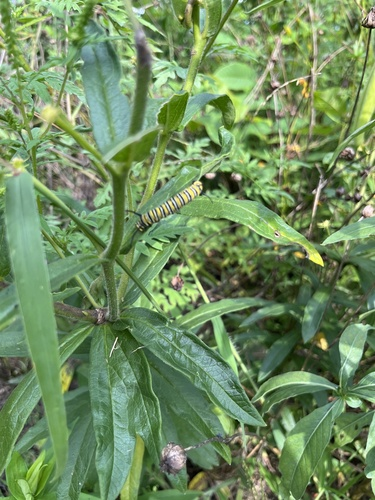

In [8]:
from PIL import Image
import os
import imageio.v2 as imageio


image_path = os.path.join(data_dir, df['image_path'].loc[0])
image = imageio.imread(image_path)

print(torch.Tensor(image).size())

Image.open(image_path)

In [29]:
# YOUR CHANGES HERE
from torch.utils.data import Dataset, DataLoader
from torchvision.models import AlexNet_Weights, EfficientNet_B0_Weights
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

MODEL_CHOICE = "alexnet"  # Options: "alexnet", "efficientnet_b0", "custom"

alexnet_train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

alexnet_val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


efficientnet_b0_train_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

efficientnet_b0_val_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


resnet_train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),  # optional but useful for insects
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

TRANSFORM_REGISTRY = {
    "alexnet": {
        "train": alexnet_train_tf,
        "val":   alexnet_val_tf,
    },
    "efficientnet_b0": {
        "train": efficientnet_b0_train_tf,
        "val":   efficientnet_b0_val_tf,
    },
    "resnet": {
        "train": resnet_train_tf, 
        "val": alexnet_val_tf,
    }, 
    "custom": {
        "train": transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.1),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.3, hue=0.1),
            transforms.RandomRotation(20),
            transforms.ToTensor(),
        ]),
        "val": transforms.Compose([transforms.ToTensor()]),
    },
}


class ButterflyDataset(Dataset):
    def __init__(self, file_name, data_dir, model_choice=MODEL_CHOICE, is_train=True):
        df = pd.read_csv(file_name)
        self.data_dir = data_dir
        self.values   = df[SPECIES].values.astype(np.float32)
        self.x = df["image_path"].values
        self.is_train = is_train

        if model_choice not in TRANSFORM_REGISTRY:
            raise ValueError(
                f"Unknown model_choice '{model_choice}'. "
                f"Choose from: {list(TRANSFORM_REGISTRY.keys())}"
            )

        split = "train" if is_train else "val"
        self.tf = TRANSFORM_REGISTRY[model_choice][split]

    def __len__(self):
        return len(self.x)

    def _load_image(self, image_url):
        img = Image.open(os.path.join(self.data_dir, image_url)).convert("RGB")
        return self.tf(img)

    def __getitem__(self, idx):
        return self._load_image(self.x[idx]), torch.from_numpy(self.values[idx])

Create a DataLoader object for the training data.

In [30]:
# YOUR CHANGES HERE

data = ButterflyDataset("train-onehot.csv", data_dir=data_dir)
loader = DataLoader(
        data,
        batch_size=32,
        shuffle=True,
)
print(len(loader)*32)

59776


In [31]:
val = ButterflyDataset("validation-onehot.csv", data_dir=data_dir)
val_loader = DataLoader(val, batch_size=254, shuffle=True) 
print(len(val_loader)*254)

10160


Explain any non-default parameter choices you made for the DataLoader.

YOUR ANSWER HERE: 

I wrote a few scripts for different data transformation and augmentation. I experimented with two different architectures. The first one was the AlexNet one which I used but my validation accuracy plateaued at 0.65 even with adding more linear learnable parameters at the end. It seems that the model is not robust enough to characterize the nuances of butterfly images. So, I searched online and switched over to EfficientNet_B0 version given its architectural advancement and complexity which can capture more fine-grained details. I looked at the source code and also utilized their custom data augmentation. This parameter allows me to quickly switch between two modes of transformations. 
There was also a second parameter called is_train because I wanted to specify different transformations depending on whether something is train/validation. For train, we want models to generalize better so the registry I wrote also included some random saturation, hue changes, color jitters, gray scale, and flips. Whereas, the validation included less changes for both alexnet and efficientnet transformations such as only resizing and recropping. 

THe other parameters were just standard to be able to locate the file and import the data. 

## Part 3: Define model structure and select an appropriate loss function.

Implement the model class for your convolutional neural network.
The final output of your model should be a tensor of probabilities for each of the ten species choices.

> Hint 1: refer to [project 1](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project1.ipynb) for an example, albeit it is most likely much to simple a model.

> Hint 2: think about models we discussed recently in class and start with one of the popular ones.

> Hint 3: this problem may benefit from starting with a model pre-trained on ImageNet in which you then finetune on this dataset.

In [12]:
import warnings
import time 
HEIGHT = 500 
WIDTH = 375

In [13]:
# YOUR CHANGES HERE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_data = ButterflyDataset("train-onehot.csv", data_dir=data_dir)
val_data =ButterflyDataset("validation-onehot.csv", data_dir=data_dir)
HEIGHT = 500 
WIDTH = 375
import os
import time
import warnings
import torch
from torch.utils.data import DataLoader
import livelossplot
import torcheval.metrics.functional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

class VisionModel(torch.nn.Module): 
    def __init__(self, num_layers, in_channels, out_channels, kernel_size, p_size, stride, data, val_data=None, device=device): 
        super().__init__()
        self.num_layers = num_layers
        self.data = data
        self.val_data = val_data
        self.in_channels = in_channels 
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.device = device
        self.p_size = p_size

        network = [] 
        network.append(torch.nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, stride=self.stride))
        network.append(torch.nn.BatchNorm2d(self.out_channels))
        network.append(torch.nn.ReLU())
        
        for _ in range(num_layers-1): 
            network.append(torch.nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, stride=self.stride)) 
            network.append(torch.nn.BatchNorm2d(self.out_channels))
            network.append(torch.nn.ReLU())
            
        network.append(torch.nn.AdaptiveAvgPool2d((self.p_size, self.p_size)))
        network.append(torch.nn.Flatten()) 
        network.append(torch.nn.Linear(self.p_size * self.p_size * self.out_channels, 10))
        network.append(torch.nn.Softmax(dim=1)) 
        
        self.network = torch.nn.DataParallel(torch.nn.Sequential(*network)) 
        
    def _save_parameters(self, name, directory="results"): 
        os.makedirs(directory, exist_ok=True)
        path = os.path.join(os.getcwd(), directory, f"{name}_model_param.pth") 
        torch.save(self.network.module.state_dict(), path)
        return path 
        
    def _init_data_loader(self, batch_size=256, shuffle=True): 
        return DataLoader(self.data, batch_size=batch_size, shuffle=shuffle) 
    def _init_val_loader(self, batch_size=1028, shuffle=False): 
        return DataLoader(self.val_data, batch_size, shuffle) 

    def forward(self, x): 
        if not isinstance(x, torch.Tensor): 
            x = torch.Tensor(x) 

        if len(x.size()) == 4 and x.size(1) != self.in_channels: 
            print(x.size())
            warnings.warn("Tensor shape mismatch: expected [batch, channels, H, W]")
        return self.network(x)

    def train_model(self, lr=1e-4, weight_decay=0, num_epochs=100, criterion=torch.nn.BCEWithLogitsLoss(), batch_size=256, shuffle=True):
        if torch.cuda.is_available():
            self.network.cuda()
        
        optimizer = torch.optim.Adam(self.network.parameters(), lr=lr, weight_decay=weight_decay)
        train_loader = self._init_data_loader(batch_size=batch_size, shuffle=shuffle)
        val_loader = self._init_val_loader(batch_size=batch_size, shuffle=False) if self.val_data is not None else None
        
        liveloss = livelossplot.PlotLosses()

        best_val_loss = float('inf')
        for epoch in range(num_epochs):
            self.network.train()
            running_train_loss = 0.0
            for i, (x_batch, y_batch) in enumerate(train_loader):
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                optimizer.zero_grad(set_to_none=True)
                y_pred = self.forward(x_batch)
                loss = criterion(y_pred, y_batch)
                print(f" Epoch: {epoch} | Batch {i} of {len(train_loader)} | Loss: {loss}") 
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item()
            
            avg_train_loss = running_train_loss / len(train_loader)
            updates = {"loss": avg_train_loss}

            if val_loader is not None:
                self.network.eval()
                val_loss_total = 0.0
                with torch.no_grad():
                    for x_val, y_val in val_loader:
                        x_val = x_val.to(self.device)
                        y_val = y_val.to(self.device)
                        y_val_pred = self.forward(x_val)
                        val_loss_total += criterion(y_val_pred, y_val).item()
                avg_val_loss = val_loss_total / len(val_loader)
                updates["val_loss"] = avg_val_loss

                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    self._save_parameters(name=str(time.time()))
            
            liveloss.update({k: torch.tensor(v) for k, v in updates.items()})
            liveloss.send()
        
        return self

vision = VisionModel(data=train_data, num_layers=5, in_channels=3, out_channels=3, kernel_size=2, p_size=5, stride=2)
d = vision._init_data_loader(batch_size=1, shuffle=False) 
x = next(iter(d))[0] 
with torch.no_grad(): 
    out = vision.forward(x) 
    print(out) 

del x
del d
del vision
del out

tensor([[0.0448, 0.0528, 0.0734, 0.1082, 0.2068, 0.0902, 0.1062, 0.1224, 0.0743,
         0.1208]], device='cuda:0')


Explain your choices for the shapes in each convolutional layer of your model.

YOUR ANSWER HERE

I first transformed the input from a [batch, 500 (height), 375 (width), 3 (channel)] by permuting the tensor into [batch, 3 (channel), 500 height, 375 width] so that I can feed it into the first convolutional layer which has a kernel size of 2. Each convolutional layer uses a kernel size of 2 and stride of 2, which aggressively downsamples the spatial dimensions of the input by approximately a factor of 2 per layer. This allows the model to rapidly reduce computational cost while extracting increasingly abstract spatial features. After five layers, the spatial resolution is reduced significantly, and an adaptive average pooling layer ensures a fixed output size of 5×5 regardless of input dimensions. Though, in hindsight, the the stride of 2 in the beginning may have been too rapid of a downsizing, so I could experiment with stride of 1 for now. 

Explain your choices for the channels in each convolutional layer of your model.

YOUR ANSWER HERE

The model maintains a constant number of channels 5 across all convolutional layers. This simplifies the architecture and reduces computational overhead, but limits the representational capacity of the network. Unlike standard CNNs that increase channel depth to capture more complex features at deeper layers, this design constrains the model to a small set of feature maps though greater than the original number of channels to ideally capture more richer hierarchical transformations. 

YOUR ANSWER HERE (important note) 

After testing many rounds with my convolutional neural network, I realize it is not robust enough and I would need a better architecture. I decided to go with a pretrained model for a simpler experience training/finetuning a CNN. As such, I have also described the shape of the ResNet 18  model before and read the literature on some of the architectural choices: 
I use ResNet because its layered structure lets me go deeper without breaking training: I start with a convolution that expands the input (e.g., 3 RGB channels -> 64 channels), then pass through multiple stages of residual blocks where channels increase (64 -> 128 -> 256 -> 512 in something like ResNet-18/34, or up to 2048 in deeper versions like ResNet-50), and each block keeps information flowing by adding the input back to the output through skip connections; this means even as I stack many layers, gradients don’t vanish and I can learn richer hierarchical features, from edges to textures to full object parts, while keeping optimization stable and efficient.

In [14]:
# YOUR CHANGES HERE
criterion = torch.nn.CrossEntropyLoss()

Explain your choice of loss function.
One sentence should suffice.

YOUR ANSWER HERE

I chose the `torch.nn.CrossEntropyLoss()`  function because it is a suitable loss function for classification tasks where the output of the neural network are unnormalized logit values (i.e., output of a linear layer not after softmax for multi-class classification or sigmoid for binary classification). 

## Part 4: Implement a training loop and explain your choices.

Implement and run an appropriate training loop.
Plot accuracy and loss for the training and validation sets for each epoch.
Plot a summary of the gradients of your choice for each epoch.

In [15]:
SPECIES_NAMES=train_species
tensor_obj = torch.Tensor(new_validation_df[SPECIES_NAMES].values)
new_validation_df['outcome'] = torch.argmax(tensor_obj, dim=1).reshape(-1,)
MODEL_CHOICE = "efficientnet"
if MODEL_CHOICE == "alexnet":
    base_model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
elif MODEL_CHOICE == "efficientnet":
    from torchvision.models import EfficientNet_B0_Weights
    from torchvision import models
    base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
print(base_model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [67]:
from torchvision import models
from torchvision.models import AlexNet_Weights, EfficientNet_B0_Weights
import os
import time
import warnings
import torch
from torch.utils.data import DataLoader
import livelossplot
import torcheval.metrics.functional

MODEL_CHOICE = "efficientnet_b0"   # "alexnet" | "efficientnet_b0" | "custom"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_data = ButterflyDataset("train-onehot.csv", data_dir=data_dir, model_choice=MODEL_CHOICE)
val_data = ButterflyDataset("validation-onehot.csv", data_dir=data_dir, model_choice=MODEL_CHOICE)


class FinetunedVision:
    def __init__(self, model, train_data, val_data, device=device,
                 directory="results", model_choice=MODEL_CHOICE):
        self.model  = model
        self.train_data = train_data
        self.val_data = val_data
        self.device= device
        self.directory  = directory
        self.model_name = MODEL_CHOICE

        self._configure_head(model_choice=model_choice)
        self.model.to(self.device)

    def _configure_head(self, model_choice):
        if model_choice == "alexnet":
            self.model.classifier.add_module("7",  torch.nn.ReLU(inplace=True))
            self.model.classifier.add_module("8",  torch.nn.Linear(1000, 10))
            self.model.classifier.add_module("9",  torch.nn.Dropout(p=0.3))
    
        elif model_choice == "efficientnet_b0":
            for param in self.model.parameters():
                param.requires_grad = False

            EXPANDED_HEAD = True
            if EXPANDED_HEAD:
                self.model.classifier = torch.nn.Sequential(
                    torch.nn.Linear(in_features=1280, out_features=640, bias=True),
                    torch.nn.ReLU(),
                    torch.nn.Dropout(p=0.2),
                    torch.nn.Linear(in_features=640, out_features=len(SPECIES), bias=True),
                    ## torch.nn.Linear(in_features=1280, out_features=160, bias=True),
                    ## torch.nn.ReLU(),
                    ## torch.nn.Dropout(p=0.2),
                    ## torch.nn.Linear(in_features=160, out_features=160, bias=True),
                    ## torch.nn.ReLU(), 
                    ## torch.nn.Dropout(p=0.2),
                    ## torch.nn.Linear(in_features=160, out_features=10, bias=True), 
                )
            else:
                self.model.classifier[1] = torch.nn.Linear(
                    in_features=1280, out_features=len(SPECIES), bias=True
                )

            # Unfreeze classifier + last two feature blocks for fine-tuning
            for param in self.model.classifier.parameters():
                param.requires_grad = True
            for param in self.model.features[-2:].parameters():
                param.requires_grad = True
        elif model_choice == "resnet": 
            in_features = self.model.fc.in_features

            self.model.fc = torch.nn.Sequential(
                torch.nn.Linear(in_features, 512),
                torch.nn.ReLU(inplace=True),
                torch.nn.Dropout(p=0.3),
                torch.nn.Linear(512, 10)
            )

        else:
            raise ValueError(
                f"Unknown model_choice '{model_choice}'. "
                f"Choose from: 'alexnet', 'efficientnet_b0', 'custom'"
            )

    def _save_parameters(self, name):
        os.makedirs(self.directory, exist_ok=True)
        path  = os.path.join(self.directory, f"{name}_model_param.pth")
        state = (self.model.module.state_dict()
                 if hasattr(self.model, "module") else self.model.state_dict())
        torch.save(state, path)
        return path

    def _init_data_loader(self, batch_size=32, shuffle=True):
        return DataLoader(self.train_data, batch_size=batch_size,
                          shuffle=shuffle, pin_memory=True)

    def _init_val_loader(self, batch_size=32):
        return DataLoader(self.val_data, batch_size=batch_size,
                          shuffle=False, pin_memory=True)

    def forward(self, x):
        return self.model(x)

    def _evaluate_loader(self, loader, criterion):
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for x_val, y_val in loader:
                x_val, y_val = x_val.to(self.device), y_val.to(self.device)
                preds = self.forward(x_val)
                total_loss += criterion(preds, y_val).item()

                predicted = torch.argmax(preds, dim=-1)
                y_idx = torch.argmax(y_val, dim=-1) if y_val.dim() > 1 else y_val
                correct += (predicted == y_idx).sum().item()
                total += y_val.size(0)

        return total_loss / len(loader), correct / total if total else 0.0

    def train_model(
        self,
        num_epochs = 20,
        lr = 1e-4,
        wd = 1e-4,
        criterion = None,
        batch_size = 32,
        mini_val_every_n_batches = 10,
    ):
        if criterion is None:
            criterion = torch.nn.CrossEntropyLoss()

        train_loader = self._init_data_loader(batch_size=batch_size)
        val_loader = self._init_val_loader(batch_size=batch_size)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=wd) if self.model_name == "resnet" else torch.optim.Adam([
                {"params": self.model.features.parameters(), "lr": 0.75 * lr, "wd": 1e-4},
                {"params": self.model.classifier.parameters(), "lr": lr, "wd": wd},
            ])

        liveloss = livelossplot.PlotLosses()
        best_val_loss = float("inf")
        global_step = 0

        try:
            for epoch in range(num_epochs):
                self.model.train()
                epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0

                for i, (x_batch, y_batch) in enumerate(train_loader):
                    x_batch = x_batch.to(self.device)
                    y_batch = y_batch.to(self.device)

                    optimizer.zero_grad(set_to_none=True)
                    preds = self.forward(x_batch)
                    loss  = criterion(preds, y_batch)
                    loss.backward()

                    optimizer.step()

                    batch_loss = loss.item()
                    predicted = torch.argmax(preds.detach(), dim=-1)
                    y_idx  = torch.argmax(y_batch, dim=-1) if y_batch.dim() > 1 else y_batch
                    batch_correct = (predicted == y_idx).sum().item()
                    batch_acc = batch_correct / y_batch.size(0)

                    epoch_loss += batch_loss
                    epoch_correct += batch_correct
                    epoch_total += y_batch.size(0)
                    global_step += 1

                    liveloss.update({"batch_loss": batch_loss, "batch_accuracy": batch_acc})
                    liveloss.send()

                    if (i + 1) % mini_val_every_n_batches == 0:
                        val_loss, val_acc = self._evaluate_loader(val_loader, criterion)
                        print(f"val @ step {global_step}: "
                              f"loss={val_loss:.4f} | acc={val_acc:.4f}")
                        liveloss.update({"val_loss": val_loss, "val_accuracy": val_acc})
                        liveloss.send()

                        if val_loss < best_val_loss:
                            best_val_loss = val_loss
                            saved = self._save_parameters("best_model")
                            print(f"New best model: {saved}")

                        self.model.train()

                avg_train_loss = epoch_loss / len(train_loader)
                avg_train_acc = epoch_correct / epoch_total if epoch_total else 0.0
                val_loss, val_acc = self._evaluate_loader(val_loader, criterion)

                print(f"\n{'─'*70}")
                print(f"Epoch {epoch:02d} | "
                      f"train_loss={avg_train_loss:.4f} train_acc={avg_train_acc:.4f} | "
                      f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
                print(f"{'─'*70}\n")

                liveloss.update({"val_loss": val_loss, "val_accuracy": val_acc})
                liveloss.send()
                self.model.train()

        except KeyboardInterrupt:
            print("Training interrupted – returning current model.")

        return self


if MODEL_CHOICE == "alexnet":
    base_model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
elif MODEL_CHOICE == "efficientnet_b0":
    base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
else:
    raise ValueError(f"Unsupported MODEL_CHOICE: '{MODEL_CHOICE}'")

ftmodel = FinetunedVision(
    model = base_model,
    train_data  = train_data,
    val_data = val_data,
    directory = "results_latest",
    model_choice = MODEL_CHOICE,
)

d = ftmodel._init_data_loader(batch_size=1, shuffle=False)
x = next(iter(d))[0]

with torch.no_grad():
    out = ftmodel.forward(x.to(device))
    print("Model probabilities:", out)
    print("Tensor size:", out.size())

del x, d, ftmodel, out

Model probabilities: tensor([[ 0.0009, -0.0411,  0.0079,  0.0127, -0.0372,  0.0717, -0.0210,  0.0699,
          0.0070, -0.0042]], device='cuda:0')
Tensor size: torch.Size([1, 10])


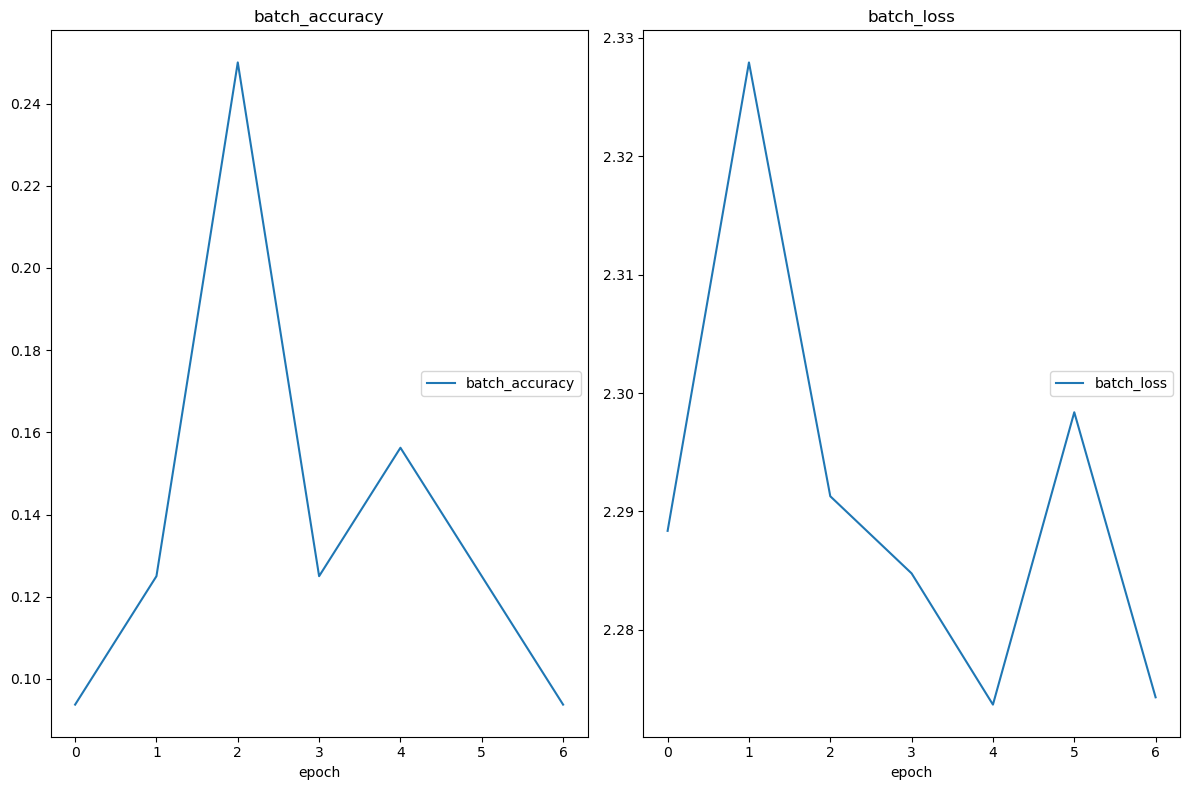

batch_accuracy
	batch_accuracy   	 (min:    0.094, max:    0.250, cur:    0.094)
batch_loss
	batch_loss       	 (min:    2.274, max:    2.328, cur:    2.274)
Training interrupted – returning current model.


In [68]:
"""note for graders... accidentally reset my run"""
MODEL_CHOICE = "efficientnet_b0"

if MODEL_CHOICE == "alexnet":
    base_model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
elif MODEL_CHOICE == "efficientnet_b0":
    from torchvision.models import EfficientNet_B0_Weights
    base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
else:
    raise ValueError(f"Unsupported MODEL_CHOICE: '{MODEL_CHOICE}'")

ftmodel = FinetunedVision(
    model = base_model,
    train_data  = train_data,
    val_data = val_data,
    directory  = "results_latest",
    model_choice = MODEL_CHOICE,
)
ftmodel.train_model(
    num_epochs  = 10,
    lr  = 1e-4,
    wd  = 1e-4,
    batch_size  = 32,
    mini_val_every_n_batches = 500,
)

In [69]:
MODEL_CHOICE = "resnet"

if MODEL_CHOICE == "resnet": 
    from torchvision.models import resnet18, ResNet18_Weights
    base_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
elif MODEL_CHOICE == "alexnet":
    base_model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
elif MODEL_CHOICE == "efficientnet_b0":
    from torchvision.models import EfficientNet_B0_Weights
    base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
else:
    raise ValueError(f"Unsupported MODEL_CHOICE: '{MODEL_CHOICE}'")

ftmodel = FinetunedVision(
    model = base_model,
    train_data   = train_data,
    val_data = val_data,
    directory  = "results_latest",
    model_choice = "resnet",
)
ftmodel.train_model(
    num_epochs  = 10,
    lr = 1e-4,
    wd = 1e-4,
    batch_size = 32,
    mini_val_every_n_batches = 750,
)

Training interrupted – returning current model.


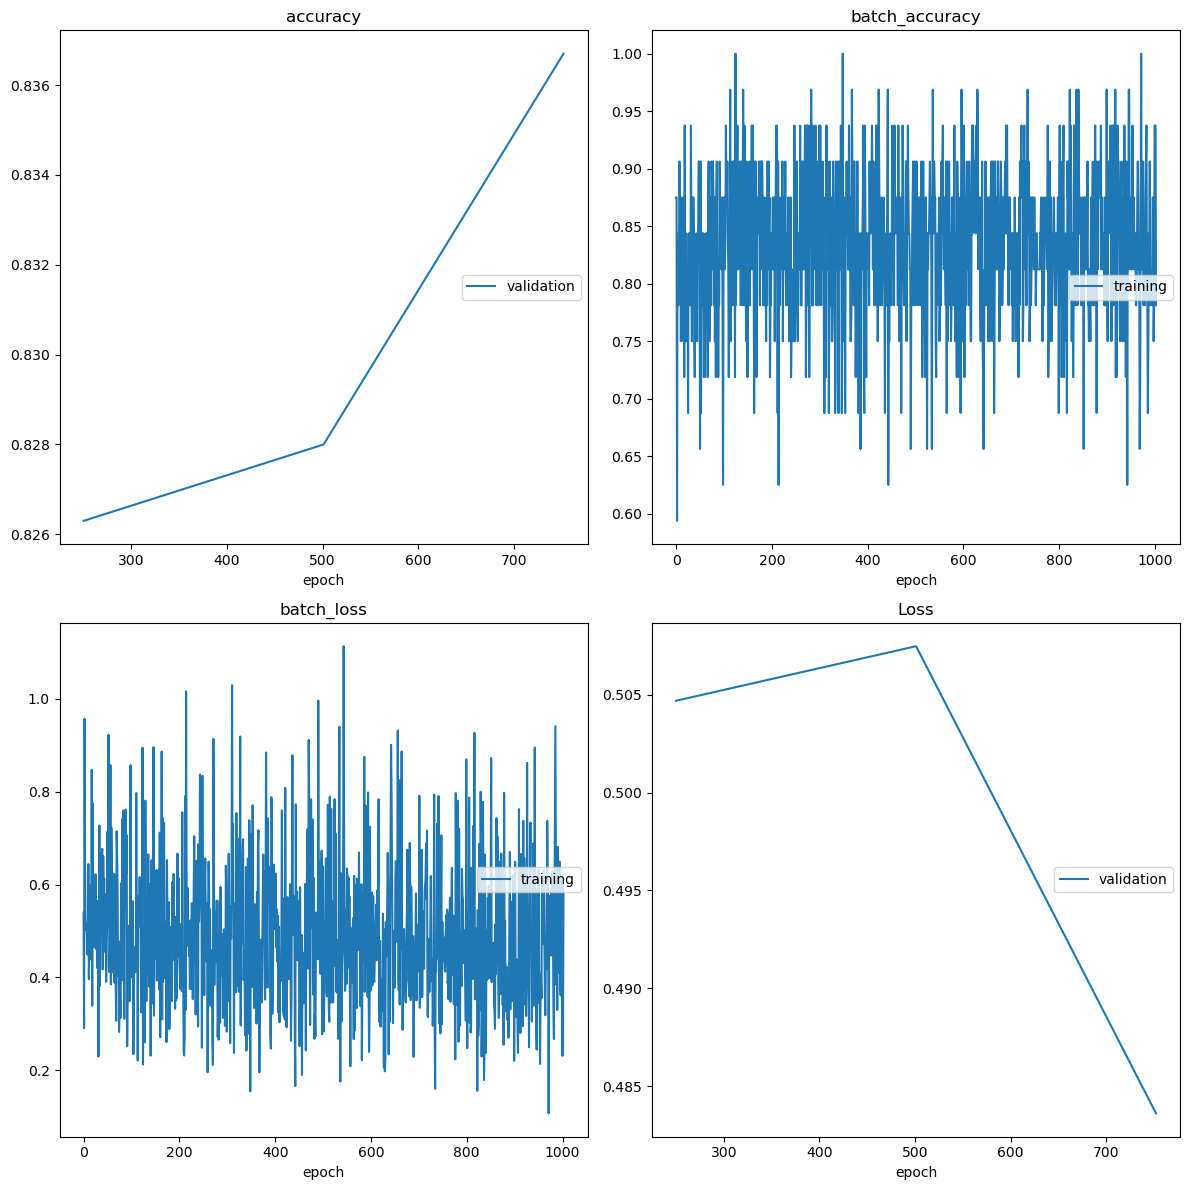

accuracy
	validation       	 (min:    0.826, max:    0.837, cur:    0.837)
batch_accuracy
	training         	 (min:    0.594, max:    1.000, cur:    0.781)
batch_loss
	training         	 (min:    0.107, max:    1.114, cur:    0.600)
Loss
	validation       	 (min:    0.484, max:    0.507, cur:    0.484)


In [ ]:
"""
Note: i may recontinue training here if i get kicked out of the SCC. This has been overwritten many times
"""
RESUME = True
MODEL_CHOICE = "resnet"
CKPT_PATH = "results_latest/best_model_model_param.pth"

if MODEL_CHOICE == "resnet": 
    from torchvision.models import resnet18, ResNet18_Weights
    base_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
elif MODEL_CHOICE == "alexnet":
    base_model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
elif MODEL_CHOICE == "efficientnet_b0":
    from torchvision.models import EfficientNet_B0_Weights
    base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
else:
    raise ValueError(f"Unsupported MODEL_CHOICE: '{MODEL_CHOICE}'")

ftmodel = FinetunedVision(
    model = base_model,
    train_data = train_data,
    val_data = val_data,
    directory = "results_latest",
    model_choice = MODEL_CHOICE,  
)

if RESUME:
    if not os.path.exists(CKPT_PATH):
        raise FileNotFoundError(f"Checkpoint not found at '{CKPT_PATH}' cannot resume.")
    ftmodel.model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
    ftmodel.model.to(device)
    print(f"Resumed from checkpoint: {CKPT_PATH}")
    ftmodel.train_model(
        num_epochs = 7,
        lr = 3e-5, 
        wd = 2e-4,
        batch_size = 32,
        mini_val_every_n_batches = 250,
    )
else:
    print("Starting fresh training run.")
    ftmodel.train_model(
        num_epochs = 20,
        lr = 1e-4,
        wd = 1e-4,
        batch_size = 32,
        mini_val_every_n_batches = 500,
    )

## Part 5: Predict species for the test set.

Use your model to predict probabilities for each of the species choices.

In [70]:
import torch
import pandas as pd
from tqdm import tqdm
from PIL import Image
import os
import numpy as np

def predict_probabilities(ft_model, df, data_dir, model_choice=MODEL_CHOICE, device=device):
    ft_model.model.eval()

    val_tf = TRANSFORM_REGISTRY[model_choice]["val"] 
    results = []

    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df)):
            img_path = os.path.join(data_dir, row["image_path"])
            try:
                img = Image.open(img_path).convert("RGB")
                x   = val_tf(img).unsqueeze(0).to(device)
            except Exception as e:
                print(f"SKIPPING {img_path}: {e}")
                continue

            preds = ft_model.forward(x)
            probs = torch.softmax(preds, dim=1).cpu().numpy()[0]

            row_result = {"uuid": row.get("uuid"), "image_file": row["image_path"]}
            for name, p in zip(SPECIES, probs):
                row_result[name] = float(p)
            results.append(row_result)

    return pd.DataFrame(results)


def import_data(t):
    return pd.read_csv(f"{data_dir}/{t}.csv")

test_df = import_data("test")
MODEL_CHOICE="resnet"
if MODEL_CHOICE == "resnet": 
    from torchvision.models import resnet18, ResNet18_Weights
    base_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
elif MODEL_CHOICE == "alexnet":
    base_model = models.alexnet(weights=AlexNet_Weights.DEFAULT)
elif MODEL_CHOICE == "efficientnet_b0":
    from torchvision.models import EfficientNet_B0_Weights
    base_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
else:
    raise ValueError(f"Unsupported MODEL_CHOICE: '{MODEL_CHOICE}'")


vision = FinetunedVision(
    model = base_model,
    train_data  = train_data,
    val_data = val_data,
    model_choice = MODEL_CHOICE, 
)
vision.model.load_state_dict(
    torch.load("results_latest/best_model_model_param.pth", map_location=device)
)
vision.model.to(device)
vision.model.eval()

test_pred_df = predict_probabilities(
    ft_model = vision,
    df = test_df,
    data_dir = data_dir,
    model_choice = MODEL_CHOICE,
    device = device,
)

print(test_pred_df.head())
test_pred_df.to_csv("results_latest/test-predictions.csv", index=False)

100%|██████████| 10000/10000 [03:16<00:00, 51.01it/s]


                                   uuid  \
0  262f0983-c2ac-46a2-84ba-edd938a848dc   
1  58f79ba7-5eda-41c6-960c-75ea3e278f9f   
2  a8fd457c-f463-440d-b575-227bc9bcf308   
3  3aa46060-b298-4063-ba4b-3a8b779bb3bf   
4  fea4c8a3-e788-4683-a311-82de6ae12366   

                                          image_file  Danaus plexippus  \
0  images-original/26/262f0983-c2ac-46a2-84ba-edd...      7.824959e-05   
1  images-original/58/58f79ba7-5eda-41c6-960c-75e...      4.270871e-05   
2  images-original/a8/a8fd457c-f463-440d-b575-227...      8.412900e-07   
3  images-original/3a/3aa46060-b298-4063-ba4b-3a8...      2.540189e-05   
4  images-original/fe/fea4c8a3-e788-4683-a311-82d...      6.326094e-05   

   Vanessa atalanta  Dione vanillae  Aglais io  Pararge aegeria  \
0          0.008712        0.894402   0.000094         0.000520   
1          0.006956        0.959373   0.000219         0.000056   
2          0.000389        0.995995   0.000004         0.000001   
3          0.228762        0

Save your predictions to "test-predictions.csv" with columns `uuid`, the top 9 species and `other`.

Submit "test-predictions.csv" to Gradescope.

## Part 6: Submit Your Notebook

Submit your notebook to Gradescope.

## Follow Up

Make sure to check the immediate auto-grader feedback in Gradescope.
It will let you know if your file formats are correct and help you catch some avoidable mistakes.